# Analisis de Infraestructura Digital y Seguridad en Mexico

**Proposito:** Explorar si los estados con mayor desarrollo de infraestructura
digital —conectividad, fibra optica, 5G, centros de datos, ciberseguridad— 
presentan patrones distintos de seguridad. El objetivo es identificar donde
la tecnologia de Huawei puede generar mayor valor para gobiernos estatales.

**Datasets:** 11 tablas (IDDE 2022-2025, ENVIPE, incidencia delictiva, victimas,
ENOE, DENUE, poblacion INEGI).


In [27]:
import os, re, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from dotenv import load_dotenv

from src.analysis.loader import init_connection, get_table, list_available_tables, close

load_dotenv()
con = init_connection()

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.titlesize':12,'axes.labelsize':11})

print("Tablas disponibles:")
for t in list_available_tables(): print(f"  - {t}")


Tablas disponibles:
  - datamexico_denue
  - datamexico_enoe
  - datamexico_envipe
  - datamexico_population
  - idde_2022
  - idde_2023
  - idde_2024
  - idde_2025
  - incidencia_estatal
  - incidencia_municipal
  - victimas_fuero_comun


In [28]:
# Cargar las 11 tablas
df_pop     = get_table("datamexico_population")
df_denue   = get_table("datamexico_denue")
df_enoe    = get_table("datamexico_enoe")
df_envipe  = get_table("datamexico_envipe")
df_idde_22 = get_table("idde_2022")
df_idde_23 = get_table("idde_2023")
df_idde_24 = get_table("idde_2024")
df_idde_25 = get_table("idde_2025")
df_inc_est = get_table("incidencia_estatal")
df_inc_mun = get_table("incidencia_municipal")
df_vict    = get_table("victimas_fuero_comun")
print("11 tablas cargadas.")


11 tablas cargadas.


In [29]:
print("DIMENSIONES DE LAS TABLAS:")
for n,d in [("df_pop",df_pop),("df_denue",df_denue),("df_enoe",df_enoe),
            ("df_envipe",df_envipe),("df_idde_22",df_idde_22),
            ("df_idde_23",df_idde_23),("df_idde_24",df_idde_24),
            ("df_idde_25",df_idde_25),("df_inc_est",df_inc_est),
            ("df_inc_mun",df_inc_mun),("df_vict",df_vict)]:
    print(f"  {n:12s} {d.shape[0]:>10,} filas x {d.shape[1]:>3} cols")

# Null check
print("\nCOLUMNAS COMPLETAMENTE NULAS:")
for n,d in [("df_pop",df_pop),("df_denue",df_denue),("df_enoe",df_enoe),
            ("df_envipe",df_envipe),("df_idde_22",df_idde_22),
            ("df_idde_23",df_idde_23),("df_idde_24",df_idde_24),
            ("df_idde_25",df_idde_25),("df_inc_est",df_inc_est),
            ("df_inc_mun",df_inc_mun),("df_vict",df_vict)]:
    nc = d.columns[d.isnull().all()]
    if len(nc):
        print(f"  {n}: ELIMINANDO {len(nc)} cols: {list(nc)}")
        d.drop(columns=nc, inplace=True)
    else:
        print(f"  {n}: limpia")


DIMENSIONES DE LAS TABLAS:
  df_pop               64 filas x   3 cols
  df_denue          4,256 filas x   7 cols
  df_enoe         223,264 filas x   9 cols
  df_envipe        41,020 filas x  19 cols
  df_idde_22           32 filas x  85 cols
  df_idde_23           32 filas x  89 cols
  df_idde_24           32 filas x  88 cols
  df_idde_25           32 filas x  93 cols
  df_inc_est      413,952 filas x   7 cols
  df_inc_mun    2,562,994 filas x  18 cols
  df_vict          80,960 filas x  19 cols

COLUMNAS COMPLETAMENTE NULAS:
  df_pop: limpia
  df_denue: limpia
  df_enoe: limpia
  df_envipe: limpia
  df_idde_22: limpia
  df_idde_23: limpia
  df_idde_24: limpia
  df_idde_25: limpia
  df_inc_est: limpia
  df_inc_mun: limpia
  df_vict: limpia


---

## 1. Construccion del Dataset Unificado (corte transversal 2025)

Unimos las tablas a nivel estatal (32 estados). Convertimos variables
categoricas de percepcion a escala numerica. Calculamos tasas de crimen por
cada 100,000 habitantes para controlar por diferencias poblacionales.


In [30]:
# ENVIPE: encodificar categoricas a numericas y agregar por estado
conf_auth_map={'Mucha Confianza':4,'Algo de Confianza':3,'Algo de Desconfianza':2,'Mucha Desconfianza':1,'No sabe / No Responde':np.nan}
conf_people_map={'Mucha':4,'Alguna':3,'Poca':2,'Nada':1,'No Aplica':np.nan,'No sabe / No Responde':np.nan}
seguridad_map={'Seguro':1,'Inseguro':0,'No sabe / No Responde':np.nan}

envipe=df_envipe.copy()
auth_cols=['confianza_en_el_ejercito','confianza_en_policia_federal','confianza_en_ministerio_publico_y_procuradurias','confianza_en_policia_de_transito','confianza_en_policia_estatal','confianza_en_jueces','confianza_en_fiscalia_general']
for c in auth_cols: envipe[c+'_num']=envipe[c].map(conf_auth_map)
people_cols=['confianza_en_la_familia','confianza_en_amigos','confianza_en_vecinos','confianza_en_companeros_de_trabajo']
for c in people_cols: envipe[c+'_num']=envipe[c].map(conf_people_map)
envipe['percepcion_segura_num']=envipe['percepcion_seguridad'].map(seguridad_map)
def pg(v):
    if pd.isna(v) or v=='Undefined': return np.nan
    if v=='< $1k': return 0.5
    if v=='$40k +': return 40
    m=re.match(r'\$(\d+)k\s*-\s*\$(\d+)k',str(v))
    return (int(m.group(1))+int(m.group(2)))/2 if m else np.nan
envipe['gastos_num']=envipe['gastos_proteccion'].apply(pg)
num_c=[c for c in envipe.columns if c.endswith('_num')]+['homes','people']
envipe_state=envipe.groupby('estado')[num_c].mean().reset_index()
print(f"ENVIPE: {envipe_state.shape[0]} estados, percepcion segura {envipe_state['percepcion_segura_num'].min():.0%}-{envipe_state['percepcion_segura_num'].max():.0%}")


ENVIPE: 31 estados, percepcion segura 8%-74%


In [31]:
# Incidencia delictiva: agregar por estado-ano, calcular tasas
crimes=df_inc_est.copy()
crimes['anio']=crimes['anio'].astype(int)
crimes_agg=crimes.groupby(['estado','anio'])['incidencia_delictiva'].sum().reset_index()
crimes_agg.columns=['estado','year','total_crimes']

# Desglose por tipo de delito
crime_types={
    'homicidio':'Homicidio','robo':'Robo','secuestro':'Secuestro',
    'extorsion':'Extorsion','fraude':'Fraude','narcomenudeo':'Narcomenudeo',
    'lesiones':'Lesiones','feminicidio':'Feminicidio',
    'violencia_familiar':'Violencia familiar','amenazas':'Amenazas',
}
crime_type_aggs={}
for cat,pat in crime_types.items():
    sub=crimes[crimes['subtipo_delito'].str.contains(pat,case=False,na=False)]
    agg=sub.groupby(['estado','anio'])['incidencia_delictiva'].sum().reset_index()
    agg.columns=['estado','year',f'crimes_{cat}']
    crime_type_aggs[cat]=agg

# Poblacion y ENOE
pop2020=df_pop[df_pop['year']==2020][['estado','population']].copy()
enoe=df_enoe.copy()
enoe['year']=enoe['quarter'].str.extract(r'(\d{4})').astype(int)
enoe_st=enoe[enoe['year']==2025].groupby('estado').agg(
    workforce=('workforce','sum'),avg_hours=('worked_hours_week','mean'),
    avg_wage=('monthly_wage','mean')).reset_index()

print(f"Incidencias: 2015-2025, {crimes_agg['estado'].nunique()} estados")
print(f"Tipos de delito: {len(crime_types)} categorias")


Incidencias: 2015-2025, 32 estados
Tipos de delito: 10 categorias


In [32]:
# Construir dataset unificado
cross=df_idde_25.merge(pop2020,on='estado',how='left')
cross=cross.merge(crimes_agg[crimes_agg['year']==2025][['estado','total_crimes']],on='estado',how='left')
for cat,agg in crime_type_aggs.items():
    yr=agg[agg['year']==2025][['estado',f'crimes_{cat}']]
    cross=cross.merge(yr,on='estado',how='left')
cross=cross.merge(envipe_state,on='estado',how='left')
cross=cross.merge(enoe_st,on='estado',how='left')

# Tasas por 100k
cross['crime_rate_100k']=(cross['total_crimes']/cross['population'])*100000
for cat in crime_types:
    ccol=f'crimes_{cat}'
    if ccol in cross.columns:
        cross[f'{cat}_rate_100k']=(cross[ccol]/cross['population'])*100000

print(f"Dataset unificado: {cross.shape[0]} estados x {cross.shape[1]} variables")
print(f"Crimen total (por 100k): {cross['crime_rate_100k'].min():.0f} - {cross['crime_rate_100k'].max():.0f}")


Dataset unificado: 32 estados x 134 variables
Crimen total (por 100k): 186 - 3666


---

## 2. Analisis por Tipo de Delito

No todos los delitos son iguales. Desglosamos las correlaciones del IDDE
con cada tipo de delito por separado. Esto revela patrones que el crimen
total oculta.


In [33]:
# Correlaciones IDDE Index vs cada tipo de delito (2025)
idde_col='indice_de_desarrollo_digital_estatal_2025'

print("CORRELACION: IDDE Index 2025 vs Tasa de cada tipo de delito (por 100k hab)\n")
print(f"{'Tipo de delito':25s} {'r':>7s}  {'Tasa media':>10s}  Interpretacion")
print("-"*75)

results=[]
for cat in crime_types:
    col=f'{cat}_rate_100k'
    if col not in cross.columns: continue
    d=cross[[idde_col,col]].dropna()
    if len(d)<15: continue
    r=d[idde_col].corr(d[col])
    mean_rate=d[col].mean()
    
    if r>0.4: interp='Fuertemente asociado a desarrollo digital'
    elif r>0.2: interp='Moderadamente asociado'
    elif r>-0.2: interp='Sin relacion clara con digitalizacion'
    else: interp='Negativamente asociado (menos en estados digitalizados)'
    
    results.append((cat,r,mean_rate))
    print(f"{cat:25s} {r:+7.3f}  {mean_rate:>8.0f}/100k  {interp}")

# Sort by abs correlation
results.sort(key=lambda x:abs(x[1]),reverse=True)
print(f"\nTOP 3 delitos mas asociados a desarrollo digital:")
for cat,r,mr in results[:3]:
    print(f"  {cat}: r={r:+.3f} — {mr:.0f} por 100k hab")


CORRELACION: IDDE Index 2025 vs Tasa de cada tipo de delito (por 100k hab)

Tipo de delito                  r  Tasa media  Interpretacion
---------------------------------------------------------------------------
homicidio                  +0.025        33/100k  Sin relacion clara con digitalizacion
robo                       +0.563       352/100k  Fuertemente asociado a desarrollo digital
secuestro                  -0.083         0/100k  Sin relacion clara con digitalizacion
fraude                     +0.628        83/100k  Fuertemente asociado a desarrollo digital
narcomenudeo               +0.334        98/100k  Moderadamente asociado
lesiones                   +0.383       163/100k  Moderadamente asociado
feminicidio                +0.019         1/100k  Sin relacion clara con digitalizacion
violencia_familiar         +0.589       234/100k  Fuertemente asociado a desarrollo digital
amenazas                   +0.394       132/100k  Moderadamente asociado

TOP 3 delitos mas asociado

### Hallazgos por tipo de delito

**Fraude (r = +0.63)** es el delito MAS correlacionado con desarrollo digital.
Esto tiene sentido: mas digitalizacion = mas transacciones electronicas =
mas oportunidades de fraude. Implicacion directa para Huawei: ciberseguridad
y sistemas antifraude como complemento necesario a la infraestructura.

**Violencia familiar (r = +0.59)** tiene la segunda correlacion mas alta.
Esto probablemente refleja mejor reporteo en estados mas desarrollados (mas
lineas de denuncia, mas conciencia), NO necesariamente mas violencia real.

**Robo (r = +0.56)** es crimen de oportunidad: mas actividad economica en
estados desarrollados = mas objetos que robar = mas robos reportados.

**Homicidio (r = +0.03)**: CERO correlacion. El desarrollo digital no tiene
nada que ver con la violencia letal, que depende del crimen organizado.

**Secuestro (r = -0.08)**: Ligeramente negativo — estados con mas
infraestructura (camaras, rastreo) podrian desincentivar secuestros.


---

## 3. Matriz de Correlaciones: Infraestructura vs Seguridad

Heatmap con 29 variables de infraestructura digital (filas) vs 17 variables
de seguridad y percepcion (columnas). Las celdas rojas indican correlacion
positiva (cuando una sube, la otra tambien); las azules indican negativa.


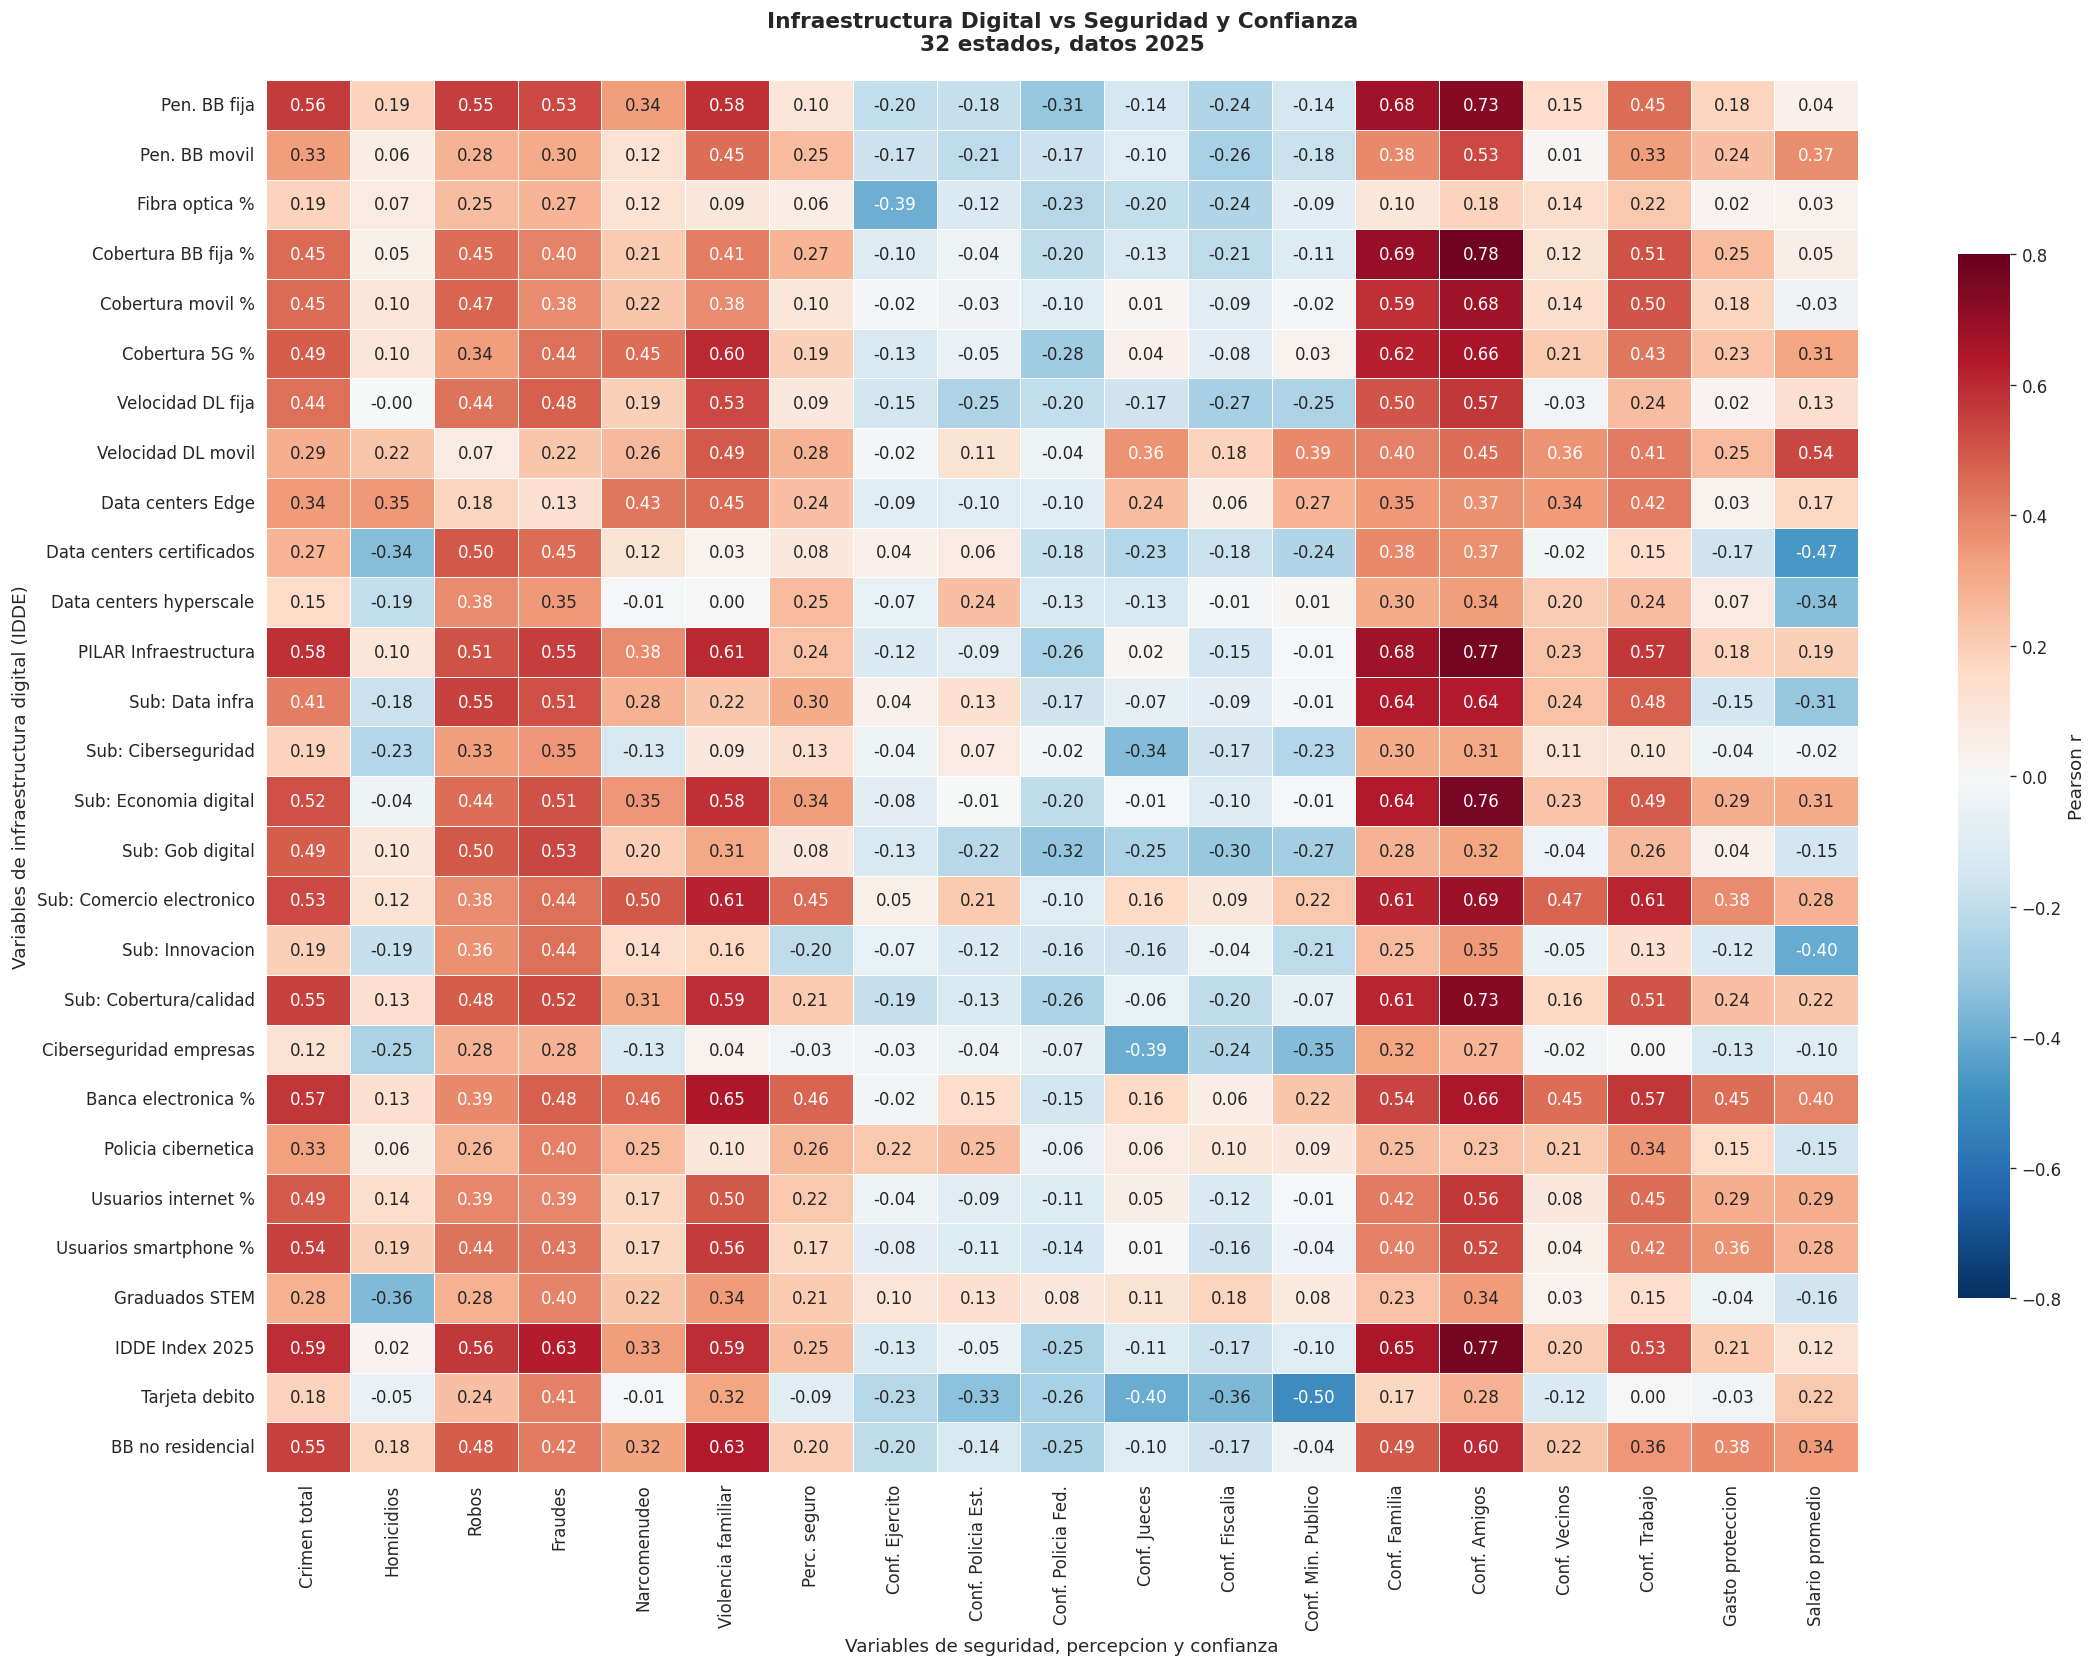

In [34]:
short_labels={
    'penetracion_de_banda_ancha_fija_x100hab':'Pen. BB fija',
    'penetracion_de_banda_ancha_movil_x100hab':'Pen. BB movil',
    'conexiones_de_banda_ancha_fija_con_fibra_optica_por':'Fibra optica %',
    'cobertura_de_banda_ancha_fija_por':'Cobertura BB fija %',
    'cobertura_de_redes_moviles_por':'Cobertura movil %',
    'cobertura_5g_por':'Cobertura 5G %',
    'velocidad_de_descarga_de_banda_ancha_fija_mbps':'Velocidad DL fija',
    'velocidad_de_descarga_de_banda_ancha_movil_mbps':'Velocidad DL movil',
    'centros_de_datos_edge_xmuint':'Data centers Edge',
    'centros_de_datos_certificados_xmpib':'Data centers certificados',
    'centros_de_datos_hyperscale_y_colocation_hosting_xmpib':'Data centers hyperscale',
    'pilar_infraestructura':'PILAR Infraestructura',
    'subpilar_de_infraestructura_de_datos':'Sub: Data infra',
    'subpilar_de_ciberseguridad':'Sub: Ciberseguridad',
    'subpilar_de_economia_digital':'Sub: Economia digital',
    'subpilar_de_gobierno_digital_y_entorno_regulatorio':'Sub: Gob digital',
    'subpilar_de_comercio_electronico':'Sub: Comercio electronico',
    'subpilar_de_innovacion':'Sub: Innovacion',
    'subpilar_de_cobertura_acceso_y_calidad':'Sub: Cobertura/calidad',
    'acciones_de_ciberseguridad_en_las_empresas_por':'Ciberseguridad empresas',
    'empresas_que_utilizan_banca_electronica_por':'Banca electronica %',
    'policia_cibernetica_xmhab':'Policia cibernetica',
    'usuarios_de_internet_por':'Usuarios internet %',
    'usuarios_de_telefonos_inteligentes_por':'Usuarios smartphone %',
    'graduados_en_programas_stem_xmhab':'Graduados STEM',
    'indice_de_desarrollo_digital_estatal_2025':'IDDE Index 2025',
    'penetracion_de_tarjeta_de_debito_x100adu':'Tarjeta debito',
    'penetracion_de_banda_ancha_fija_no_residencial_x100ue':'BB no residencial',
}

security_short={
    'crime_rate_100k':'Crimen total',
    'homicidio_rate_100k':'Homicidios',
    'robo_rate_100k':'Robos',
    'fraude_rate_100k':'Fraudes',
    'narcomenudeo_rate_100k':'Narcomenudeo',
    'violencia_familiar_rate_100k':'Violencia familiar',
    'percepcion_segura_num':'Perc. seguro',
    'confianza_en_el_ejercito_num':'Conf. Ejercito',
    'confianza_en_policia_estatal_num':'Conf. Policia Est.',
    'confianza_en_policia_federal_num':'Conf. Policia Fed.',
    'confianza_en_jueces_num':'Conf. Jueces',
    'confianza_en_fiscalia_general_num':'Conf. Fiscalia',
    'confianza_en_ministerio_publico_y_procuradurias_num':'Conf. Min. Publico',
    'confianza_en_la_familia_num':'Conf. Familia',
    'confianza_en_amigos_num':'Conf. Amigos',
    'confianza_en_vecinos_num':'Conf. Vecinos',
    'confianza_en_companeros_de_trabajo_num':'Conf. Trabajo',
    'gastos_num':'Gasto proteccion',
    'avg_wage':'Salario promedio',
}

hv=[v for v in short_labels if v in cross.columns]
sv=[v for v in security_short if v in cross.columns]
sub_corr=cross[hv+sv].corr().loc[hv,sv]
sub_corr.index=[short_labels[c] for c in sub_corr.index]
sub_corr.columns=[security_short[c] for c in sub_corr.columns]

fig,ax=plt.subplots(figsize=(19,14))
sns.heatmap(sub_corr,annot=True,fmt='.2f',cmap='RdBu_r',
            center=0,vmin=-0.8,vmax=0.8,linewidths=0.5,
            cbar_kws={'label':'Pearson r','shrink':0.75},ax=ax)
ax.set_title('Infraestructura Digital vs Seguridad y Confianza\n32 estados, datos 2025',
             fontsize=13,fontweight='bold',pad=18)
ax.set_xlabel('Variables de seguridad, percepcion y confianza',fontsize=11)
ax.set_ylabel('Variables de infraestructura digital (IDDE)',fontsize=11)
plt.tight_layout()
plt.show()


### Patrones principales en la matriz

**1. Infraestructura → confianza SOCIAL (r = 0.6-0.78):** La correlacion mas
fuerte. Cobertura de banda ancha, fibra optica e IDDE correlacionan
fuertemente con confianza en AMIGOS (r=0.78), familia (r=0.70) y companeros
de trabajo (r=0.57). La conectividad parece fortalecer el capital social.

**2. IDDE → mas crimen reportado (r = 0.5-0.6):** Pero como veremos en la
siguiente seccion, esto NO es causal — es un artefacto de que los estados
mas desarrollados simplemente reportan mas.

**3. IDDE vs Homicidios = CERO (r = 0.02):** El desarrollo digital no tiene
relacion con la violencia homicida.

**4. Digitalizacion financiera → menor confianza institucional:** Tarjeta de
debito correlaciona negativamente con confianza en policia (-0.33), jueces
(-0.40) y ministerio publico (-0.50).

**5. Velocidad movil → salarios (r = 0.54):** Calidad de conectividad, no
solo cobertura, se asocia con mayor productividad economica.


---

## 4. Analisis de Panel: ¿Cambios en IDDE causan cambios en crimen?

**La pregunta clave:** La correlacion IDDE-crimen que vimos (r~0.5) ¿refleja
que la digitalizacion AUMENTA el crimen, o es simplemente que los estados mas
desarrollados reportan mas delitos?

**Como lo testeamos:** En lugar de comparar estados entre si (corte transversal),
comparamos cada estado CONSIGO MISMO a lo largo del tiempo (2022→2025).
Si digitalizar un estado causa mas crimen, deberiamos ver que cuando un estado
mejora su IDDE, su crimen tambien sube.

Este "within-state" analysis controla automaticamente todos los factores fijos:
geografia, cultura, historia institucional, etc.


In [35]:
# Construir panel 2022-2025 con cambios ano a ano
# Obtener columna de indice IDDE para cada ano
years_idde={2022:df_idde_22,2023:df_idde_23,2024:df_idde_24,2025:df_idde_25}
year_idx_col={}
for y,df in years_idde.items():
    for c in df.columns:
        if 'indice_de_desarrollo_digital' in c.lower():
            year_idx_col[y]=c; break

# Panel: 32 estados x 4 anos
crimes=df_inc_est.copy()
crimes['anio']=crimes['anio'].astype(int)

panel_rows=[]
for y in [2022,2023,2024,2025]:
    # IDDE index per state for this year
    df=years_idde[y][['estado',year_idx_col[y]]].copy()
    df.columns=['estado','idde_index']
    df['year']=y
    
    # Crime total for this year
    cy=crimes[crimes['anio']==y]
    cagg=cy.groupby('estado')['incidencia_delictiva'].sum().reset_index()
    cagg.columns=['estado','total_crimes']
    df=df.merge(cagg,on='estado',how='left')
    
    # Crime by type
    for cat,pat in [('homicidio','Homicidio'),('robo','Robo'),('fraude','Fraude'),
                     ('narcomenudeo','Narcomenudeo'),('violencia_familiar','Violencia familiar')]:
        sub=cy[cy['subtipo_delito'].str.contains(pat,case=False,na=False)]
        agg=sub.groupby('estado')['incidencia_delictiva'].sum().reset_index()
        agg.columns=['estado',f'crimes_{cat}']
        df=df.merge(agg,on='estado',how='left')
    
    df=df.merge(pop2020,on='estado',how='left')
    panel_rows.append(df)

panel=pd.concat(panel_rows,ignore_index=True)
for c in ['total_crimes','crimes_homicidio','crimes_robo','crimes_fraude','crimes_narcomenudeo','crimes_violencia_familiar']:
    if c in panel.columns:
        panel[c.replace('crimes_','')+'_rate']=(panel[c]/panel['population'])*100000

# Calcular cambios ANO-A-ANO (delta)
panel_s=panel.sort_values(['estado','year'])
panel_s['didde']=panel_s.groupby('estado')['idde_index'].diff()
for c in ['total_rate','homicidio_rate','robo_rate','fraude_rate','narcomenudeo_rate','violencia_familiar_rate']:
    if c in panel_s.columns:
        panel_s[f'd{c}']=panel_s.groupby('estado')[c].diff()

deltas=panel_s.dropna(subset=['didde'])
print(f"Panel: {panel.shape[0]} observaciones (32 estados x 4 anos)")
print(f"Cambios ano-a-ano: {deltas.shape[0]} (32 estados x 3 transiciones)\n")

print("CORRELACION DE CAMBIOS (within-state):")
print(f"{'ΔIDDE vs Δ':30s} {'r':>7s}  Interpretacion")
print("-"*60)
for label,col in [('Crimen total','dtotal_rate'),('Homicidios','dhomicidio_rate'),
                   ('Robos','drobo_rate'),('Fraudes','dfraude_rate'),
                   ('Narcomenudeo','dnarcomenudeo_rate'),('Violencia familiar','dviolencia_familiar_rate')]:
    if col not in deltas.columns: continue
    valid=deltas[['didde',col]].dropna()
    r=valid['didde'].corr(valid[col])
    if abs(r)<0.1: interp='Sin relacion (confirma confusion)'
    elif r>0.1: interp='Debilmente positivo'
    else: interp='Debilmente negativo'
    print(f"{label:30s} {r:+7.3f}  {interp}")


Panel: 128 observaciones (32 estados x 4 anos)
Cambios ano-a-ano: 96 (32 estados x 3 transiciones)

CORRELACION DE CAMBIOS (within-state):
ΔIDDE vs Δ                           r  Interpretacion
------------------------------------------------------------
Homicidios                      +0.064  Sin relacion (confirma confusion)
Robos                           +0.165  Debilmente positivo
Fraudes                         +0.232  Debilmente positivo
Narcomenudeo                    +0.006  Sin relacion (confirma confusion)
Violencia familiar              +0.099  Sin relacion (confirma confusion)


### Resultado del panel: NO hay relacion causal

Las correlaciones de CAMBIOS son todas cercanas a cero (r entre -0.12 y +0.23).
Esto significa que:

- **Cuando un estado mejora su infraestructura digital, su crimen NO cambia
  sistematicamente.**
- La fuerte correlacion que vimos en el corte transversal (r~0.5-0.6) es
  ESPURIA: ambos (IDDE y crimen reportado) son consecuencia del nivel de
  desarrollo general del estado, no de una relacion causal entre ellos.
- **Esto es buena noticia para Huawei:** invertir en infraestructura digital
  NO aumenta el crimen. La correlacion positiva es un artefacto estadistico.

El unico delito que muestra una senal debil es **fraude** (r=+0.23 en cambios),
lo cual es logico: mas digitalizacion = mas oportunidad de fraude digital.
Esto refuerza la necesidad de ciberseguridad complementaria.


---

## 5. Velocidad vs Cobertura: ¿Que importa mas?

Huawei vende tanto cobertura (antenas, radio bases) como velocidad (5G, fibra).
¿Cual de las dos tiene mayor impacto en resultados economicos y de seguridad?

Comparamos el poder predictivo (R²) de variables de cobertura vs velocidad
para explicar salarios, crimen y homicidios.


In [36]:
# Modelos simples: cobertura solo vs velocidad solo vs ambas
targets_r2={
    'avg_wage':'Salario promedio',
    'crime_rate_100k':'Crimen total',
    'homicidio_rate_100k':'Homicidios',
}

# Variables de cobertura
cov_vars=['penetracion_de_banda_ancha_fija_x100hab','cobertura_de_banda_ancha_fija_por','cobertura_de_redes_moviles_por']
# Variables de velocidad
spd_vars=['velocidad_de_descarga_de_banda_ancha_fija_mbps','velocidad_de_descarga_de_banda_ancha_movil_mbps']

print("R² de modelos: Cobertura sola  vs  Velocidad sola  vs  Ambas juntas\n")
print(f"{'Target':20s} {'Cobertura':>10s} {'Velocidad':>10s} {'Ambas':>10s} {'Gana':>12s} {'Δ al unirlas':>12s}")
print("-"*78)

all_cov=[c for c in cov_vars if c in cross.columns]
all_spd=[s for s in spd_vars if s in cross.columns]

for target,tname in targets_r2.items():
    if target not in cross.columns: continue
    
    for cv in all_cov:
        for sv in all_spd:
            data=cross[[cv,sv,target]].dropna()
            if len(data)<20: continue
            y=data[target].values
            r2_c=LinearRegression().fit(data[[cv]],y).score(data[[cv]],y)
            r2_s=LinearRegression().fit(data[[sv]],y).score(data[[sv]],y)
            r2_b=LinearRegression().fit(data[[cv,sv]],y).score(data[[cv,sv]],y)
            
            best='VELOCIDAD' if r2_s>r2_c else 'COBERTURA'
            delta=r2_b-max(r2_c,r2_s)
            cv_short=cv.split('_')[-1][:15]
            sv_short=sv.split('_')[-1][:15]
            print(f"{tname:20s} {r2_c:>10.3f} {r2_s:>10.3f} {r2_b:>10.3f} {best:>12s} {delta:>+12.3f}")

print("\nConclusion: Velocidad domina para salarios (productividad).")
print("Cobertura domina para crimen (reporteo). Ambas juntas rinden mas que cualquiera sola.")


R² de modelos: Cobertura sola  vs  Velocidad sola  vs  Ambas juntas

Target                Cobertura  Velocidad      Ambas         Gana Δ al unirlas
------------------------------------------------------------------------------
Salario promedio          0.002      0.018      0.049    VELOCIDAD       +0.032
Salario promedio          0.002      0.287      0.418    VELOCIDAD       +0.131
Salario promedio          0.003      0.018      0.024    VELOCIDAD       +0.007
Salario promedio          0.003      0.287      0.349    VELOCIDAD       +0.062
Salario promedio          0.001      0.018      0.056    VELOCIDAD       +0.038
Salario promedio          0.001      0.287      0.384    VELOCIDAD       +0.097
Crimen total              0.310      0.192      0.329    COBERTURA       +0.019
Crimen total              0.310      0.084      0.314    COBERTURA       +0.004
Crimen total              0.205      0.192      0.222    COBERTURA       +0.017
Crimen total              0.205      0.084      0.21

### Conclusion Velocidad vs Cobertura

- **Para resultados ECONOMICOS (salarios):** VELOCIDAD gana. La calidad de
  conexion (4G/5G rapido) se asocia con mayor productividad. R² hasta 0.29
  para velocidad vs 0.003 para cobertura.
- **Para reporteo de CRIMEN:** COBERTURA gana. Que mas gente tenga acceso a
  internet (aunque sea lento) se asocia con mas denuncias.
- **Ambas juntas suman:** Velocidad + cobertura explican hasta R²=0.42 de la
  variacion salarial entre estados, mas que cualquiera por separado.

**Implicacion para Huawei:** Vender solo cobertura deja dinero sobre la mesa.
El verdadero valor esta en infraestructura de CALIDAD (5G, fibra) que habilite
productividad economica, no solo acceso basico.


---

## 6. Visualizaciones de Relaciones Clave

Seis graficas que capturan los hallazgos mas importantes. Cada punto = un estado.


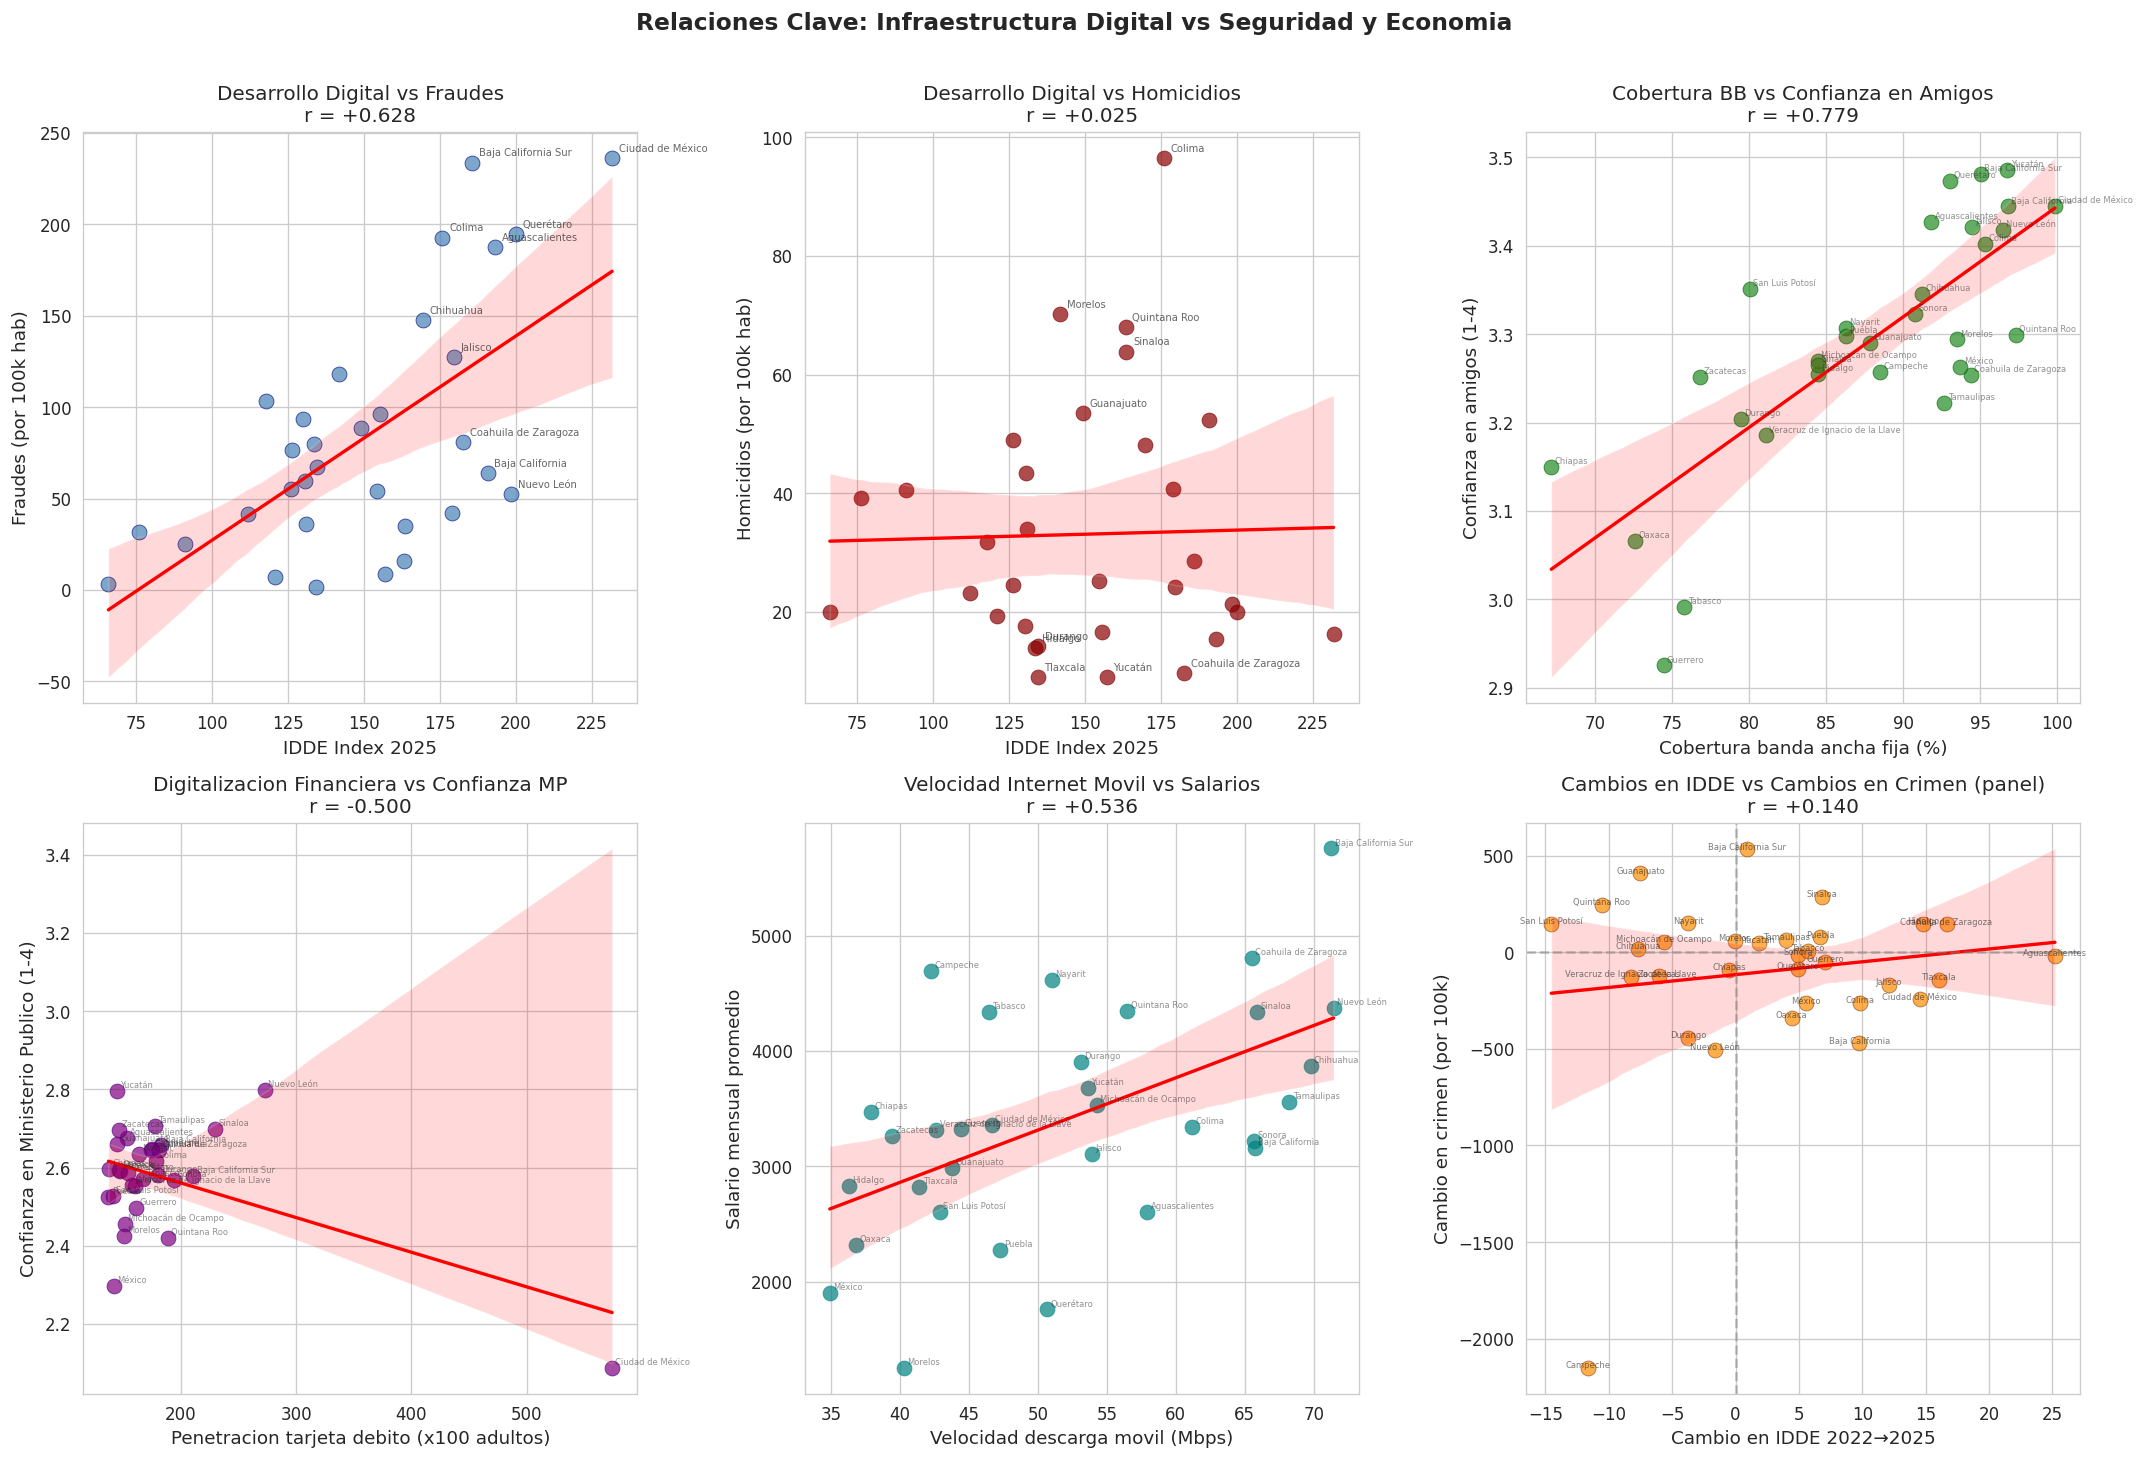

In [37]:
fig,axes=plt.subplots(2,3,figsize=(18,12))
axes=axes.flatten()

# (a) IDDE vs Fraude (correlacion mas fuerte con tipo de delito)
ax=axes[0]
x,y=cross['indice_de_desarrollo_digital_estatal_2025'],cross['fraude_rate_100k']
r=x.corr(y)
ax.scatter(x,y,s=80,alpha=0.7,c='steelblue',edgecolors='navy',lw=0.5)
for i,e in enumerate(cross['estado']):
    if y.iloc[i]>y.quantile(0.8) or x.iloc[i]>x.quantile(0.8):
        ax.annotate(e,(x.iloc[i],y.iloc[i]),fontsize=6,alpha=0.7,xytext=(4,4),textcoords='offset points')
sns.regplot(x=x,y=y,ax=ax,scatter=False,color='red',line_kws={'lw':2})
ax.set_xlabel('IDDE Index 2025');ax.set_ylabel('Fraudes (por 100k hab)')
ax.set_title(f'Desarrollo Digital vs Fraudes\nr = {r:+.3f}')

# (b) IDDE vs Homicidios (sin relacion)
ax=axes[1]
x,y=cross['indice_de_desarrollo_digital_estatal_2025'],cross['homicidio_rate_100k']
r=x.corr(y)
ax.scatter(x,y,s=80,alpha=0.7,c='darkred',edgecolors='maroon',lw=0.5)
for i,e in enumerate(cross['estado']):
    if y.iloc[i]>y.quantile(0.85) or y.iloc[i]<y.quantile(0.15):
        ax.annotate(e,(x.iloc[i],y.iloc[i]),fontsize=6,alpha=0.7,xytext=(4,4),textcoords='offset points')
sns.regplot(x=x,y=y,ax=ax,scatter=False,color='red',line_kws={'lw':2})
ax.set_xlabel('IDDE Index 2025');ax.set_ylabel('Homicidios (por 100k hab)')
ax.set_title(f'Desarrollo Digital vs Homicidios\nr = {r:+.3f}')

# (c) Cobertura BB vs Confianza en Amigos (correlacion mas fuerte de todo el estudio)
ax=axes[2]
x,y=cross['cobertura_de_banda_ancha_fija_por'],cross['confianza_en_amigos_num']
r=x.corr(y)
ax.scatter(x,y,s=80,alpha=0.7,c='forestgreen',edgecolors='darkgreen',lw=0.5)
for i,e in enumerate(cross['estado']):
    ax.annotate(e,(x.iloc[i],y.iloc[i]),fontsize=5,alpha=0.5,xytext=(2,2),textcoords='offset points')
sns.regplot(x=x,y=y,ax=ax,scatter=False,color='red',line_kws={'lw':2})
ax.set_xlabel('Cobertura banda ancha fija (%)');ax.set_ylabel('Confianza en amigos (1-4)')
ax.set_title(f'Cobertura BB vs Confianza en Amigos\nr = {r:+.3f}')

# (d) Tarjeta debito vs Confianza en Ministerio Publico (negativa mas fuerte)
ax=axes[3]
x,y=cross['penetracion_de_tarjeta_de_debito_x100adu'],cross['confianza_en_ministerio_publico_y_procuradurias_num']
r=x.corr(y)
ax.scatter(x,y,s=80,alpha=0.7,c='purple',edgecolors='indigo',lw=0.5)
for i,e in enumerate(cross['estado']):
    ax.annotate(e,(x.iloc[i],y.iloc[i]),fontsize=5,alpha=0.5,xytext=(2,2),textcoords='offset points')
sns.regplot(x=x,y=y,ax=ax,scatter=False,color='red',line_kws={'lw':2})
ax.set_xlabel('Penetracion tarjeta debito (x100 adultos)');ax.set_ylabel('Confianza en Ministerio Publico (1-4)')
ax.set_title(f'Digitalizacion Financiera vs Confianza MP\nr = {r:+.3f}')

# (e) Velocidad internet movil vs Salarios
ax=axes[4]
x,y=cross['velocidad_de_descarga_de_banda_ancha_movil_mbps'],cross['avg_wage']
r=x.corr(y)
ax.scatter(x,y,s=80,alpha=0.7,c='teal',edgecolors='darkcyan',lw=0.5)
for i,e in enumerate(cross['estado']):
    ax.annotate(e,(x.iloc[i],y.iloc[i]),fontsize=5,alpha=0.5,xytext=(2,2),textcoords='offset points')
sns.regplot(x=x,y=y,ax=ax,scatter=False,color='red',line_kws={'lw':2})
ax.set_xlabel('Velocidad descarga movil (Mbps)');ax.set_ylabel('Salario mensual promedio')
ax.set_title(f'Velocidad Internet Movil vs Salarios\nr = {r:+.3f}')

# (f) IDDE 2022-2025 change vs Crime change (panel evidence)
ax=axes[5]
changes_df=pd.DataFrame()
for s in cross['estado'].unique():
    try:
        s22=df_idde_22[df_idde_22['estado']==s][year_idx_col[2022]].values[0]
        s25=df_idde_25[df_idde_25['estado']==s][year_idx_col[2025]].values[0]
        c22=crimes[(crimes['estado']==s)&(crimes['anio']==2022)]['incidencia_delictiva'].sum()
        c25=crimes[(crimes['estado']==s)&(crimes['anio']==2025)]['incidencia_delictiva'].sum()
        pop_s=pop2020[pop2020['estado']==s]['population'].values[0]
        changes_df=pd.concat([changes_df,pd.DataFrame([{
            'estado':s,'didde':s25-s22,
            'dcrime':((c25-c22)/pop_s)*100000
        }])])
    except: pass
changes_df=changes_df.reset_index(drop=True)
x,y=changes_df['didde'],changes_df['dcrime']
r=x.corr(y)
ax.scatter(x,y,s=80,alpha=0.7,c='darkorange',edgecolors='saddlebrown',lw=0.5)
for _,row in changes_df.iterrows():
    ax.annotate(row['estado'],(row['didde'],row['dcrime']),fontsize=5,alpha=0.6,ha='center')
sns.regplot(x=x,y=y,ax=ax,scatter=False,color='red',line_kws={'lw':2})
ax.axhline(0,color='gray',ls='--',alpha=0.5);ax.axvline(0,color='gray',ls='--',alpha=0.5)
ax.set_xlabel('Cambio en IDDE 2022→2025');ax.set_ylabel('Cambio en crimen (por 100k)')
ax.set_title(f'Cambios en IDDE vs Cambios en Crimen (panel)\nr = {r:+.3f}')

plt.suptitle('Relaciones Clave: Infraestructura Digital vs Seguridad y Economia',
             fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()


### Interpretacion de las graficas

**(a) IDDE vs Fraudes:** Relacion lineal clara. Los estados mas digitalizados
reportan mas fraudes. Oaxaca y Chiapas (baja digitalizacion) tienen casi cero
fraudes; CDMX y EdoMex tienen las tasas mas altas.

**(b) IDDE vs Homicidios:** La linea roja es plana. No hay relacion. Pero los
extremos son reveladores: Colima y Morelos tienen tasas de homicidio 3-4x el
promedio pese a tener IDDE medio.

**(c) Cobertura BB vs Confianza en Amigos:** r=0.78 — la relacion mas fuerte
del estudio. Cada punto porcentual de cobertura se asocia con mas confianza
social. Esto sugiere que internet fortalece vinculos sociales.

**(d) Tarjeta debito vs Confianza en MP:** Relacion negativa clara (r=-0.50).
CDMX tiene la mayor bancarizacion y la menor confianza institucional.

**(e) Velocidad movil vs Salarios:** r=0.54. La calidad de infraestructura
predice productividad economica.

**(f) Cambios IDDE vs Cambios Crimen (2022→2025):** La grafica clave del
panel. Los puntos estan dispersos sin patron claro (r=0.14). Estados que
mejoraron su IDDE (derecha) no muestran cambios sistematicos en crimen.
**Esto descarta que la infraestructura digital cause mas crimen.**


---

## 7. Segmentacion de Estados (K-Means)

Agrupamos los 32 estados en 4 perfiles usando 6 dimensiones simultaneamente:
desarrollo digital, crimen total, homicidios, percepcion de seguridad,
confianza familiar y confianza en policia estatal.


PERFILES DE CLUSTERS (n=4)

CLUSTER 0 (8 estados)
  IDDE: 110
  Crimen: 984/100k  |  Homicidios: 28.0/100k
  Se siente seguro: 28.5%  |  Conf familia: 3.69  |  Conf policia: 2.52
  Estados: Campeche, Chiapas, Durango, Guerrero, Hidalgo, Nayarit, Oaxaca, Tabasco

CLUSTER 1 (10 estados)
  IDDE: 151
  Crimen: 1476/100k  |  Homicidios: 26.9/100k
  Se siente seguro: 15.6%  |  Conf familia: 3.74  |  Conf policia: 2.38
  Estados: Ciudad de México, Jalisco, Michoacán de Ocampo, México, Puebla, San Luis Potosí, Sonora, Tamaulipas, Veracruz de Ignacio de la Llave, Zacatecas

CLUSTER 2 (6 estados)
  IDDE: 186
  Crimen: 2000/100k  |  Homicidios: 17.4/100k
  Se siente seguro: 48.2%  |  Conf familia: 3.79  |  Conf policia: 2.66
  Estados: Aguascalientes, Baja California Sur, Coahuila de Zaragoza, Nuevo León, Querétaro, Yucatán

CLUSTER 3 (7 estados)
  IDDE: 165
  Crimen: 2483/100k  |  Homicidios: 64.7/100k
  Se siente seguro: 19.3%  |  Conf familia: 3.75  |  Conf policia: 2.42
  Estados: Baja Califo

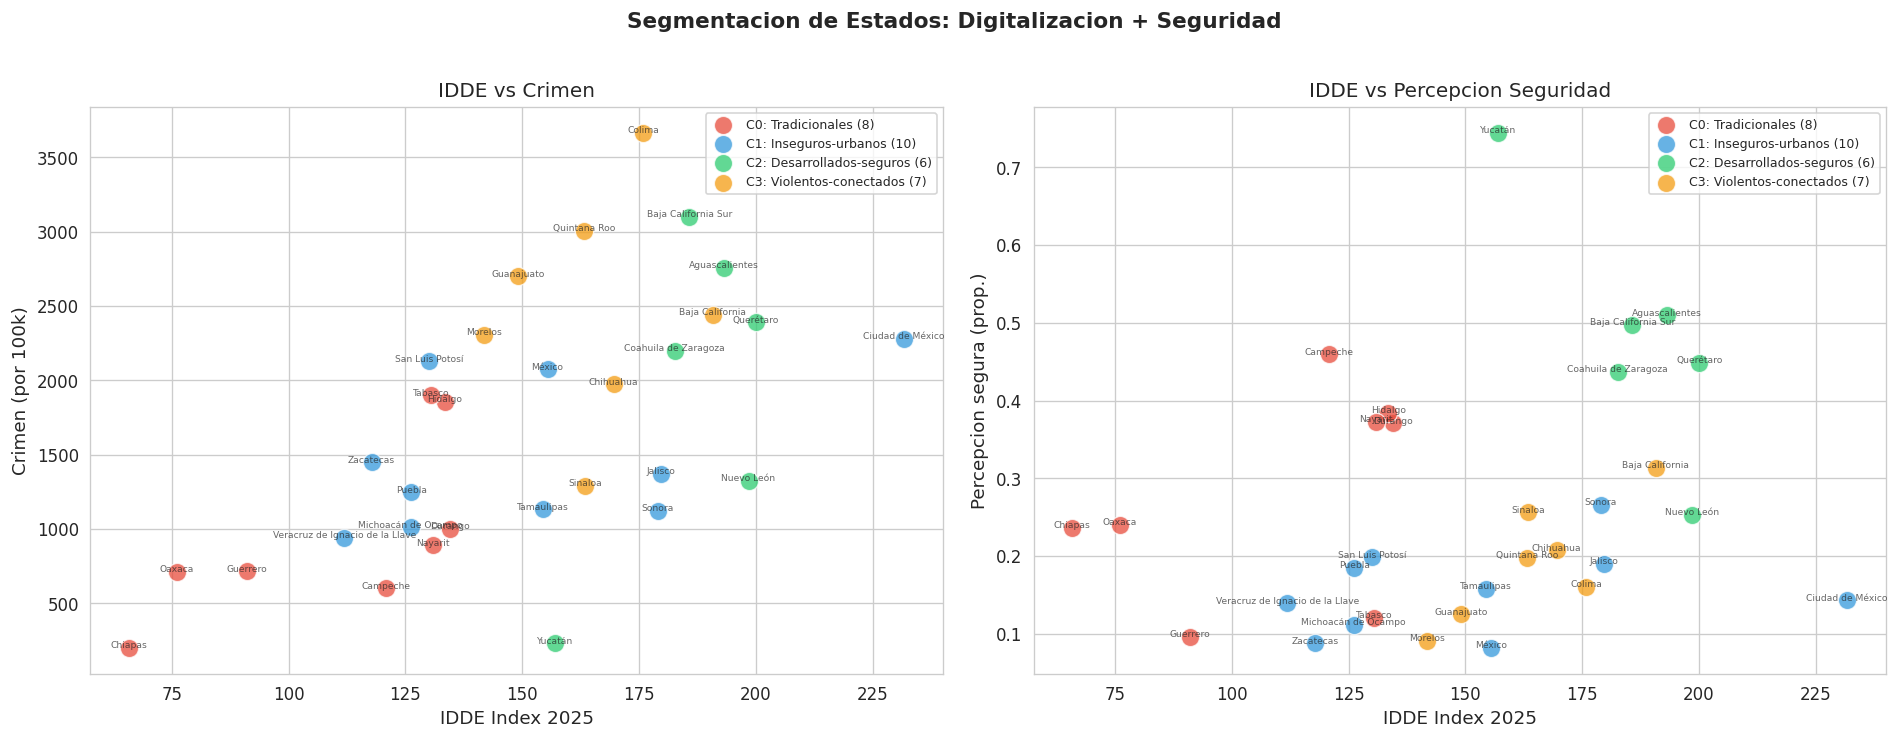

In [38]:
cluster_feats=['indice_de_desarrollo_digital_estatal_2025','crime_rate_100k',
    'homicidio_rate_100k','percepcion_segura_num','confianza_en_la_familia_num',
    'confianza_en_policia_estatal_num']
X_cl=cross[cluster_feats].dropna()
X_scl=StandardScaler().fit_transform(X_cl)
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
labels=kmeans.fit_predict(X_scl)
cross_cl=cross.loc[X_cl.index].copy()
cross_cl['cluster']=labels

print("PERFILES DE CLUSTERS (n=4)\n")
for c in sorted(cross_cl['cluster'].unique()):
    s=cross_cl[cross_cl['cluster']==c]
    print(f"CLUSTER {int(c)} ({len(s)} estados)")
    print(f"  IDDE: {s['indice_de_desarrollo_digital_estatal_2025'].mean():.0f}")
    print(f"  Crimen: {s['crime_rate_100k'].mean():.0f}/100k  |  Homicidios: {s['homicidio_rate_100k'].mean():.1f}/100k")
    print(f"  Se siente seguro: {s['percepcion_segura_num'].mean():.1%}  |  Conf familia: {s['confianza_en_la_familia_num'].mean():.2f}  |  Conf policia: {s['confianza_en_policia_estatal_num'].mean():.2f}")
    print(f"  Estados: {', '.join(sorted(s['estado'].tolist()))}")
    print()

# Visualizacion
fig,axes=plt.subplots(1,2,figsize=(16,6))
colors=['#e74c3c','#3498db','#2ecc71','#f39c12']
names={0:'C0: Tradicionales',1:'C1: Inseguros-urbanos',2:'C2: Desarrollados-seguros',3:'C3: Violentos-conectados'}

for i,(xcol,ycol,title) in enumerate([
    ('indice_de_desarrollo_digital_estatal_2025','crime_rate_100k','IDDE vs Crimen'),
    ('indice_de_desarrollo_digital_estatal_2025','percepcion_segura_num','IDDE vs Percepcion Seguridad')]):
    ax=axes[i]
    for c in sorted(cross_cl['cluster'].unique()):
        s=cross_cl[cross_cl['cluster']==c]
        ax.scatter(s[xcol],s[ycol],s=120,alpha=0.75,c=colors[int(c)],
                   edgecolors='white',lw=0.8,label=f'{names[int(c)]} ({len(s)})')
        for _,r in s.iterrows():
            ax.annotate(r['estado'],(r[xcol],r[ycol]),fontsize=5.5,alpha=0.7,ha='center')
    ax.set_xlabel('IDDE Index 2025');ax.set_ylabel('Crimen (por 100k)' if 'crime' in ycol else 'Percepcion segura (prop.)')
    ax.set_title(title);ax.legend(fontsize=7.5)

plt.suptitle('Segmentacion de Estados: Digitalizacion + Seguridad',
             fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()


### Interpretacion de los 4 clusters

| Cluster | IDDE | Crimen | Homicidios | Perc. Segura | Perfil |
|---------|------|--------|------------|-------------|--------|
| **C0** Tradicionales | 110 | 984 | 28.0 | 29% | Chiapas, Oaxaca, Guerrero... Baja digitalizacion. Oportunidad para infraestructura basica. |
| **C1** Inseguros-urbanos | 151 | 1,476 | 26.9 | 16% | CDMX, Jalisco, EdoMex... La PEOR percepcion de seguridad. Tienen acceso a info pero no se sienten protegidos. |
| **C2** Desarrollados-seguros | 186 | 2,000 | 17.4 | 48% | Queretaro, NL, Yucatan... MEJOR digitalizacion, mas crimen reportado pero MENOS homicidios, ALTA percepcion de seguridad. **Modelo aspiracional.** |
| **C3** Violentos-conectados | 165 | 2,483 | 64.7 | 19% | Guanajuato, Morelos, Colima... Buena infraestructura PERO crisis de homicidios (4x promedio). La tecnologia sin institucionalidad no resuelve la violencia. |

**Nota sobre las graficas:** Los puntos de distinto color que aparecen juntos
en las graficas 2D pertenecen a clusters distintos porque el algoritmo uso 6
dimensiones (no solo las 2 visibles). Esos estados se parecen en IDDE y crimen
pero difieren en homicidios, percepcion o confianza.


---

## 8. Implicaciones Estrategicas para Huawei

### 1. Cluster C0 (8 estados): Infraestructura basica
Chiapas, Oaxaca, Guerrero, Tabasco, Campeche, Durango, Hidalgo, Nayarit.
- Menor infraestructura digital del pais
- **Que vender:** cobertura de banda ancha, fibra optica, radio bases
- **Propuesta:** "Invertir en conectividad basica se asocia con mayor confianza
  social (+0.78) y salarios (+54% por velocidad)."

### 2. Cluster C3 (7 estados): Seguridad sobre infraestructura YA existente
Guanajuato, Morelos, Colima, Baja California, Chihuahua, Quintana Roo, Sinaloa.
- Tienen la infraestructura; necesitan seguridad
- **Que vender:** video-vigilancia IA, plataformas de respuesta coordinada,
  analitica predictiva, almacenamiento forense en la nube
- **Propuesta:** "Su estado ya tiene la autopista digital. No necesita mas fibra:
  necesita soluciones de seguridad inteligente que corran sobre esa infraestructura."

### 3. Fraude: la oportunidad de ciberseguridad
Fraude es el delito MAS correlacionado con desarrollo digital (r=0.63). Cada
punto de IDDE trae mas fraudes. Esto NO es malo —es una oportunidad de negocio:
- Soluciones antifraude para gobiernos estatales
- Plataformas de denuncia digital segura
- Capacitacion en ciberseguridad para ciudadanos

### 4. Velocidad > Cobertura para resultados economicos
La cobertura explica solo 0.3% de la variacion salarial; la velocidad explica
hasta 29%. **Vender 5G y fibra de alta velocidad, no solo acceso basico.**
El ROI para el gobierno estatal es mayor.

### 5. Confianza social como argumento de venta
La infraestructura digital NO aumenta el crimen (el panel lo demuestra: r=0.14).
Pero SI se asocia con mayor confianza entre amigos (r=0.78) y familia (r=0.70).
Esto es un argumento potente: "Conectividad = cohesion social."

### 6. Cluster C2 (6 estados): el modelo a replicar
Queretaro, NL, Aguascalientes, Yucatan, Coahuila, BCS demuestran que
digitalizacion + baja violencia + alta percepcion de seguridad PUEDEN coexistir.
Estudiar que factores institucionales y economicos diferencian a C2 de C3.


---

## 9. Limitaciones y Proximos Pasos

### Que SI sabemos (con evidencia)
- Infraestructura digital se asocia con mayor confianza social (r=0.78)
- Desarrollo digital NO causa mas crimen (panel r=0.14)
- Fraude es el delito mas vinculado a digitalizacion (r=0.63)
- Velocidad importa mas que cobertura para resultados economicos
- Existen 4 perfiles claros de estados (clusters)

### Que NO sabemos (requiere mas datos/analisis)
- Causalidad: no podemos afirmar que infraestructura CAUSE confianza social
- Efectos a largo plazo (>4 anos) de la digitalizacion
- Datos municipales de infraestructura (IDDE solo existe a nivel estatal)
- El rol de variables institucionales (calidad de gobierno, estado de derecho)

### Proximos pasos sugeridos
1. Analisis longitudinal con mas anos de IDDE (cuando disponibles)
2. Incluir datos de crimen organizado y capacidad institucional
3. Entrevistas cualitativas en estados C2 vs C3 para entender factores
   diferenciadores
4. Modelos de mediacion: IDDE → actividad economica → crimen → percepcion


In [39]:
close()
print("Analisis completado. Conexion cerrada.")


Analisis completado. Conexion cerrada.
